In [94]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.decomposition import PCA
from matplotlib.backends.backend_pdf import PdfPages
pdf = PdfPages('wine_naivebayes_report.pdf')

In [95]:
wine=load_wine()
wine

{'data': array([[1.423e+01, 1.710e+00, 2.430e+00, ..., 1.040e+00, 3.920e+00,
         1.065e+03],
        [1.320e+01, 1.780e+00, 2.140e+00, ..., 1.050e+00, 3.400e+00,
         1.050e+03],
        [1.316e+01, 2.360e+00, 2.670e+00, ..., 1.030e+00, 3.170e+00,
         1.185e+03],
        ...,
        [1.327e+01, 4.280e+00, 2.260e+00, ..., 5.900e-01, 1.560e+00,
         8.350e+02],
        [1.317e+01, 2.590e+00, 2.370e+00, ..., 6.000e-01, 1.620e+00,
         8.400e+02],
        [1.413e+01, 4.100e+00, 2.740e+00, ..., 6.100e-01, 1.600e+00,
         5.600e+02]], shape=(178, 13)),
 'target': array([0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0,
        0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,
        1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1,

In [96]:
dir(wine)

['DESCR', 'data', 'feature_names', 'frame', 'target', 'target_names']

In [97]:
df=pd.DataFrame(wine.data, columns=wine.feature_names)

In [98]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [99]:
df['target']=wine.target

In [100]:
df

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0,0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0,0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0,0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0,0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0,2
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0,2
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0,2
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0,2


In [101]:
x=df.drop('target', axis=1)

In [102]:
x

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
0,14.23,1.71,2.43,15.6,127.0,2.80,3.06,0.28,2.29,5.64,1.04,3.92,1065.0
1,13.20,1.78,2.14,11.2,100.0,2.65,2.76,0.26,1.28,4.38,1.05,3.40,1050.0
2,13.16,2.36,2.67,18.6,101.0,2.80,3.24,0.30,2.81,5.68,1.03,3.17,1185.0
3,14.37,1.95,2.50,16.8,113.0,3.85,3.49,0.24,2.18,7.80,0.86,3.45,1480.0
4,13.24,2.59,2.87,21.0,118.0,2.80,2.69,0.39,1.82,4.32,1.04,2.93,735.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
173,13.71,5.65,2.45,20.5,95.0,1.68,0.61,0.52,1.06,7.70,0.64,1.74,740.0
174,13.40,3.91,2.48,23.0,102.0,1.80,0.75,0.43,1.41,7.30,0.70,1.56,750.0
175,13.27,4.28,2.26,20.0,120.0,1.59,0.69,0.43,1.35,10.20,0.59,1.56,835.0
176,13.17,2.59,2.37,20.0,120.0,1.65,0.68,0.53,1.46,9.30,0.60,1.62,840.0


In [103]:
y=df.target

In [104]:
y

0      0
1      0
2      0
3      0
4      0
      ..
173    2
174    2
175    2
176    2
177    2
Name: target, Length: 178, dtype: int64

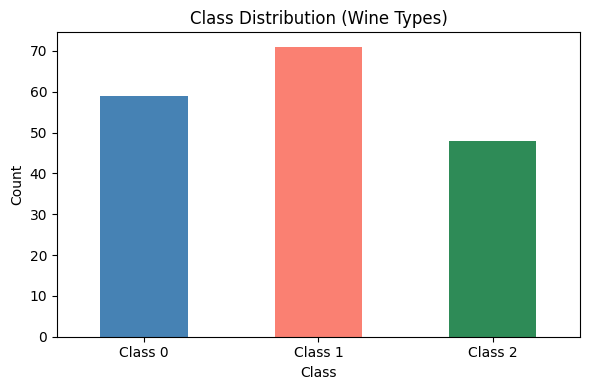

In [105]:
plt.figure(figsize=(6, 4))
pd.Series(y).value_counts().sort_index().plot(kind='bar', color=['steelblue','salmon','seagreen'])
plt.title('Class Distribution (Wine Types)')
plt.xlabel('Class')
plt.ylabel('Count')
plt.xticks(ticks=[0,1,2], labels=['Class 0','Class 1','Class 2'], rotation=0)
plt.tight_layout()
pdf.savefig()
plt.show()

In [25]:
from sklearn.model_selection import train_test_split


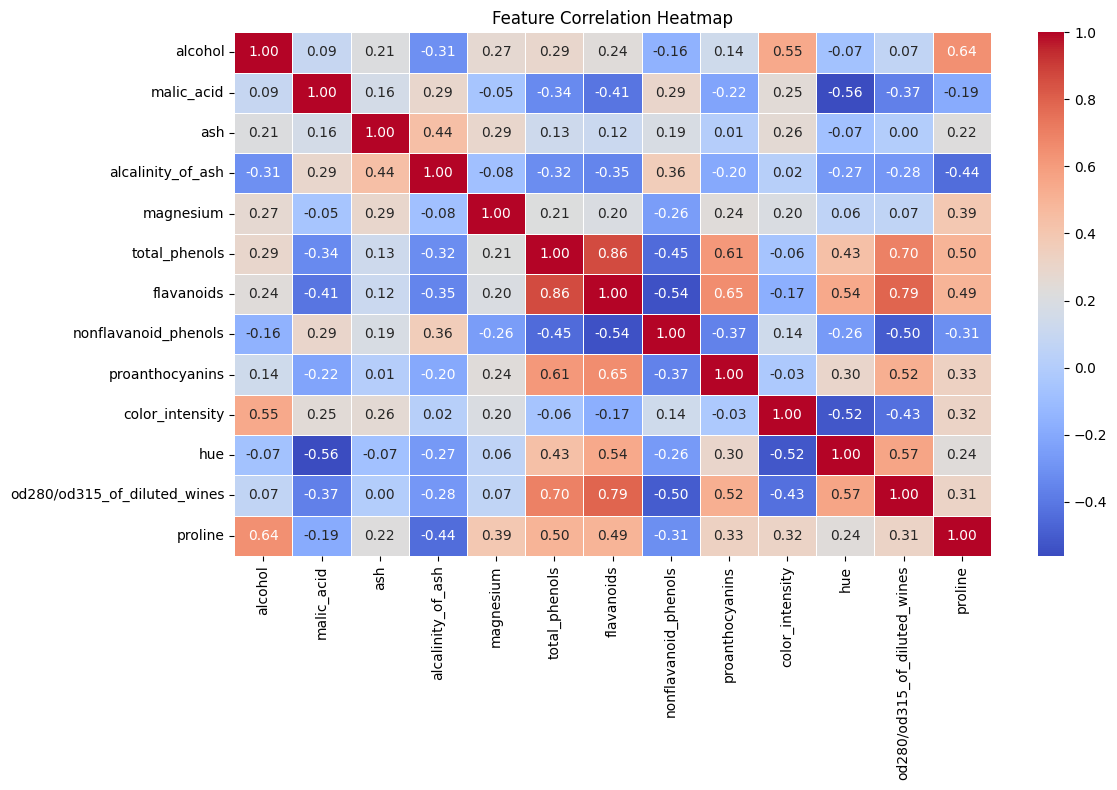

In [106]:
plt.figure(figsize=(12, 8))
sns.heatmap(df.drop('target', axis=1).corr(), annot=True, fmt='.2f', cmap='coolwarm', linewidths=0.5)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
pdf.savefig()
plt.show()

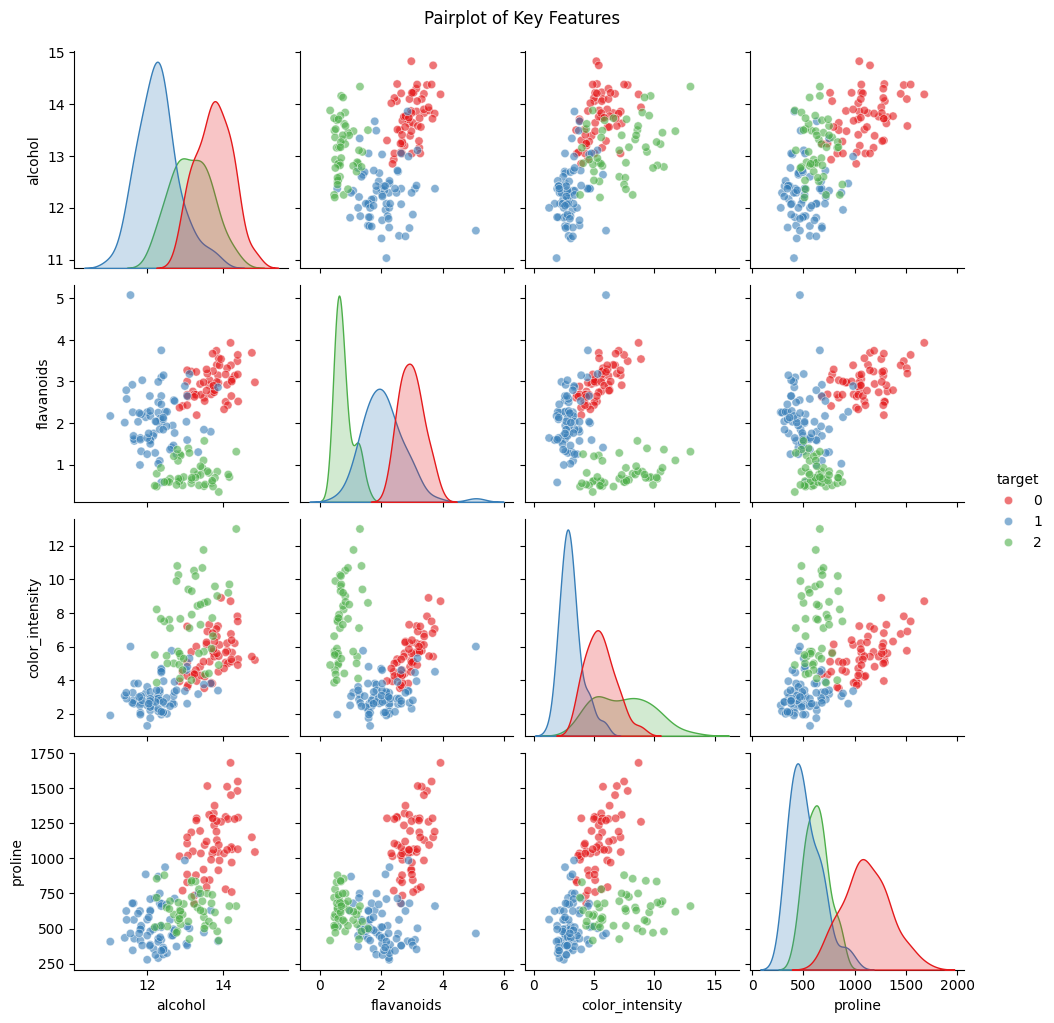

In [108]:
top_features = ['alcohol', 'flavanoids', 'color_intensity', 'proline']
sns.pairplot(df[top_features + ['target']], hue='target', palette='Set1', plot_kws={'alpha': 0.6})
plt.suptitle('Pairplot of Key Features', y=1.02)
pdf.savefig()
plt.show()

In [26]:
X_train, X_test, y_train, y_test=train_test_split(x,y,test_size=.3,random_state=42)

In [ ]:
fig, axes = plt.subplots(4, 4, figsize=(18, 14))
axes = axes.flatten()
feature_cols = df.drop('target', axis=1).columns.tolist()
for i, feat in enumerate(feature_cols):
    df.boxplot(column=feat, by='target', ax=axes[i], patch_artist=True)
    axes[i].set_title(feat, fontsize=9)
    axes[i].set_xlabel('Class')
for j in range(i+1, len(axes)):
    axes[j].set_visible(False)
plt.suptitle('Feature Distributions by Wine Class')
plt.tight_layout()
plt.savefig('Feature Distribution by wine.png')
pdf.savefig()
plt.show()

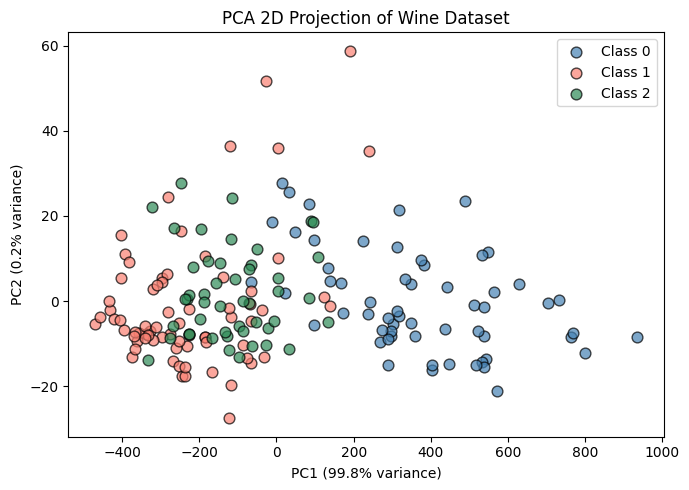

In [121]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(x)
plt.figure(figsize=(7, 5))
for cls, color, label in zip([0,1,2], ['steelblue','salmon','seagreen'], ['Class 0','Class 1','Class 2']):
    mask = y == cls
    plt.scatter(X_pca[mask, 0], X_pca[mask, 1], c=color, label=label, alpha=0.7, edgecolors='k', s=60)
plt.title('PCA 2D Projection of Wine Dataset')
plt.xlabel(f'PC1 ({pca.explained_variance_ratio_[0]*100:.1f}% variance)')
plt.ylabel(f'PC2 ({pca.explained_variance_ratio_[1]*100:.1f}% variance)')
plt.legend()
plt.tight_layout()
plt.savefig('PCA 2D projection of wine.png')
pdf.savefig()
plt.show()

In [49]:
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB , GaussianNB
from sklearn.preprocessing import StandardScaler, MinMaxScaler

In [50]:
clf1=Pipeline(
    [
        ('scaler', StandardScaler() ),
        ('Gaussian',GaussianNB() )
    ]
)
clf2=Pipeline(
    [
        ('Scaler', MinMaxScaler() ),
        ('Multinomial', MultinomialNB() )
    ]
)

In [51]:
clf1.fit(X_train,y_train)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('scaler', ...), ('Gaussian', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True
,"priors priors: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
,"var_smoothing var_smoothing: float, default=1e-9Portion of the largest variance of all features that is added tovariances for calculation stability... versionadded:: 0.20",1e-09


In [52]:
X_train

,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline
138,13.49,3.59,2.19,19.5,88.0,1.62,0.48,0.58,0.88,5.70,0.81,1.82,580.0
104,12.51,1.73,1.98,20.5,85.0,2.20,1.92,0.32,1.48,2.94,1.04,3.57,672.0
78,12.33,0.99,1.95,14.8,136.0,1.90,1.85,0.35,2.76,3.40,1.06,2.31,750.0
36,13.28,1.64,2.84,15.5,110.0,2.60,2.68,0.34,1.36,4.60,1.09,2.78,880.0
93,12.29,2.83,2.22,18.0,88.0,2.45,2.25,0.25,1.99,2.15,1.15,3.30,290.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
71,13.86,1.51,2.67,25.0,86.0,2.95,2.86,0.21,1.87,3.38,1.36,3.16,410.0
106,12.25,1.73,2.12,19.0,80.0,1.65,2.03,0.37,1.63,3.40,1.00,3.17,510.0
14,14.38,1.87,2.38,12.0,102.0,3.30,3.64,0.29,2.96,7.50,1.20,3.00,1547.0
92,12.69,1.53,2.26,20.7,80.0,1.38,1.46,0.58,1.62,3.05,0.96,2.06,495.0


In [53]:
clf2.fit(X_train,y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('Scaler', ...), ('Multinomial', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"feature_range feature_range: tuple (min, max), default=(0, 1)Desired range of transformed data.","(0, ...)"
,"copy copy: bool, default=TrueSet to False to perform inplace row normalization and avoid acopy (if the input is already a numpy array).",True
,"clip clip: bool, default=FalseSet to True to clip transformed values of held-out data toprovided `feature_range`.Since this parameter will clip values, `inverse_transform` may notbe able to restore the original data... note:: Setting `clip=True` does not prevent feature drift (a distribution shift between training and test data). The transformed values are clipped to the `feature_range`, which helps avoid unintended behavior in models sensitive to out-of-range inputs (e.g. linear models). Use with care, as clipping can distort the distribution of test data... versionadded:: 0.24",False
,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None


In [55]:
clf1.score(X_test,y_test)

1.0

In [56]:
clf2.score(X_test,y_test)

0.9629629629629629

In [65]:
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

In [66]:
import seaborn as sns

In [68]:
y_pred1 = clf1.predict(X_test)
y_pred2 = clf2.predict(X_test)
class_names = wine.target_names

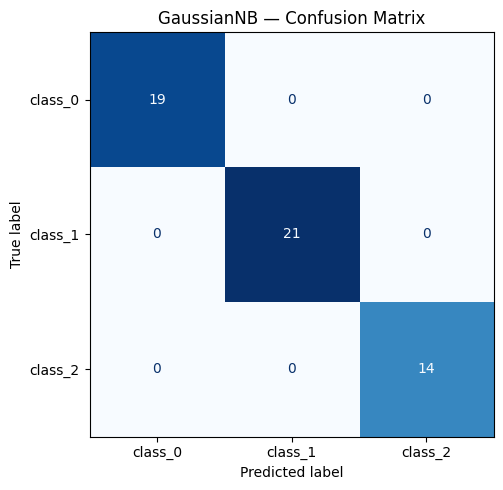

In [120]:
# confustion matrix
cm1 = confusion_matrix(y_test, y_pred1)
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm1, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp1.plot(ax=ax, cmap='Blues', colorbar=False)
ax.set_title('GaussianNB — Confusion Matrix')
plt.tight_layout()
plt.savefig('GaussianNB confusion matrix.png')
pdf.savefig()
plt.show()

In [71]:
# classification report
print("GaussianNB Classification Report:")
print(classification_report(y_test, y_pred1, target_names=class_names))

GaussianNB Classification Report:
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        19
     class_1       1.00      1.00      1.00        21
     class_2       1.00      1.00      1.00        14

    accuracy                           1.00        54
   macro avg       1.00      1.00      1.00        54
weighted avg       1.00      1.00      1.00        54



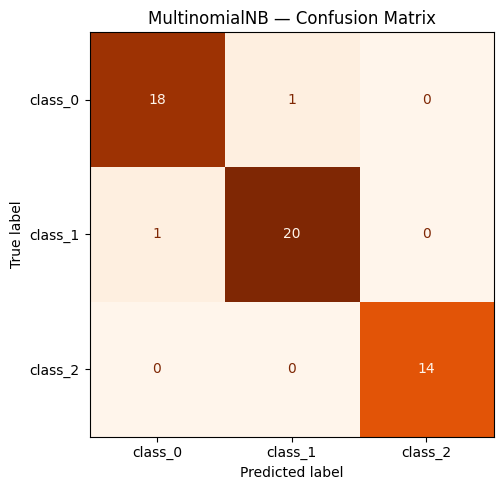

MultinomialNB Classification Report:
              precision    recall  f1-score   support

     class_0       0.95      0.95      0.95        19
     class_1       0.95      0.95      0.95        21
     class_2       1.00      1.00      1.00        14

    accuracy                           0.96        54
   macro avg       0.97      0.97      0.97        54
weighted avg       0.96      0.96      0.96        54



In [119]:
cm2 = confusion_matrix(y_test, y_pred2)
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm2, display_labels=class_names)
fig, ax = plt.subplots(figsize=(6, 5))
disp2.plot(ax=ax, cmap='Oranges', colorbar=False)
ax.set_title('MultinomialNB — Confusion Matrix')
plt.tight_layout()
plt.savefig('MultimodelNB_confusion Matrix.png')
pdf.savefig()
plt.show()

#  Classification Report — MultinomialNB
print("MultinomialNB Classification Report:")
print(classification_report(y_test, y_pred2, target_names=class_names))


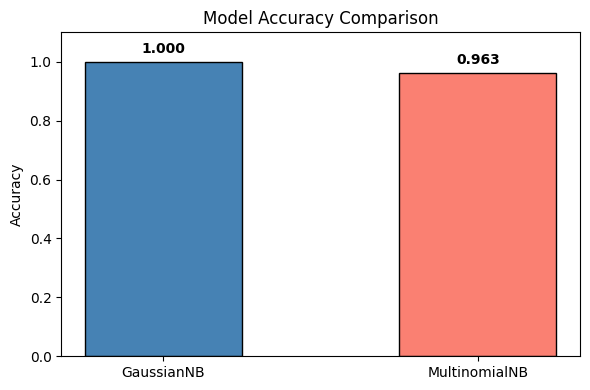

In [118]:
models  = ['GaussianNB', 'MultinomialNB']
scores  = [clf1.score(X_test, y_test), clf2.score(X_test, y_test)]
colors  = ['steelblue', 'salmon']

plt.figure(figsize=(6, 4))
bars = plt.bar(models, scores, color=colors, edgecolor='k', width=0.5)
plt.ylim(0, 1.1)
plt.ylabel('Accuracy')
plt.title('Model Accuracy Comparison')
for bar, score in zip(bars, scores):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{score:.3f}', ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.savefig('Model_Accuracy_comparison.png')
pdf.savefig()
plt.show()

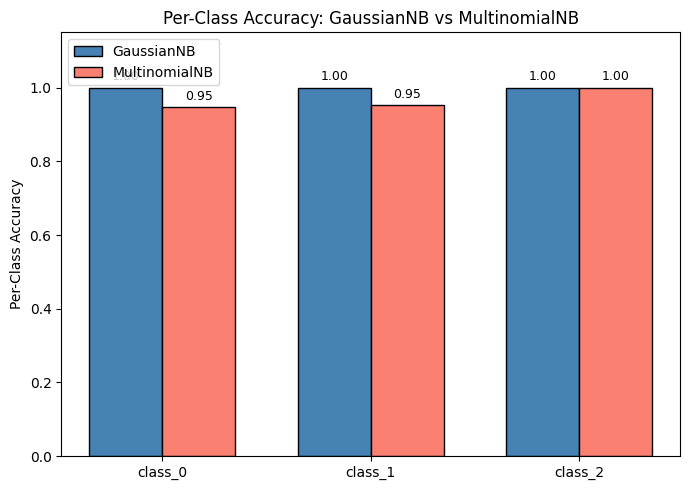

In [117]:
# per class accuracy bar chart
def per_class_accuracy(cm):
    return cm.diagonal() / cm.sum(axis=1)

pca1 = per_class_accuracy(cm1)
pca2 = per_class_accuracy(cm2)
x_pos = np.arange(len(class_names))
width = 0.35

fig, ax = plt.subplots(figsize=(7, 5))
ax.bar(x_pos - width/2, pca1, width, label='GaussianNB',    color='steelblue', edgecolor='k')
ax.bar(x_pos + width/2, pca2, width, label='MultinomialNB', color='salmon',    edgecolor='k')
ax.set_xticks(x_pos)
ax.set_xticklabels(class_names)
ax.set_ylabel('Per-Class Accuracy')
ax.set_ylim(0, 1.15)
ax.set_title('Per-Class Accuracy: GaussianNB vs MultinomialNB')
ax.legend()
for i, (v1, v2) in enumerate(zip(pca1, pca2)):
    ax.text(i - width/2, v1 + 0.02, f'{v1:.2f}', ha='center', fontsize=9)
    ax.text(i + width/2, v2 + 0.02, f'{v2:.2f}', ha='center', fontsize=9)
plt.tight_layout()
plt.savefig('per_class Accuracy.png')
pdf.savefig()
plt.show()

In [85]:
import pickle

In [88]:
# saving model 
with open ("model_pickle",'wb') as f:
    pickle.dump("model_pickle",f)

In [89]:
# load model
with open ("model_pickle", 'rb') as f:
    model= pickle.load(f)

In [115]:
pdf.close()
print("Saved: wine_naivebayes_report.pdf")

Saved: wine_naivebayes_report.pdf
